<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_FNO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [2]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.decomposition import PCA


# reproducibility

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# publication style

mpl.rcParams.update({
    "figure.dpi":110,
    "savefig.dpi":220,
    "font.family":"serif",
    "font.serif":["DejaVu Serif"],
    "mathtext.fontset":"cm",
    "axes.titlesize":11,
    "axes.labelsize":10,
    "xtick.labelsize":9,
    "ytick.labelsize":9,
    "legend.fontsize":9,
    "axes.spines.top":False,
    "axes.spines.right":False,
})


# output folders

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)


# FNO Hyperparameters

WIDTH = 40            # latent channel width (matches PINN hidden size)
MODES = 16            # retained Fourier modes
N_FNO_LAYERS = 4      # Fourier blocks
NX = 256
NT = 100


# SAE Hyperparameters

DICT = 128            # overcomplete dictionary
LAM_L1 = 5e-2
SAE_EPOCHS = 500


# FNO Training

FNO_EPOCHS = 100
LR = 1e-3
BATCH_SIZE = 20

Device: cpu


# 2. FNO Architecture

In [3]:
# Spectral Convolution Layer (1D)

class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.scale = 1 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            self.scale * torch.randn(in_channels,out_channels,modes,dtype=torch.cfloat)
        )

    def compl_mul1d(self, x, weights):
        return torch.einsum("bix,iox->box", x, weights)

    def forward(self, x):

        batchsize = x.shape[0]
        x_ft = torch.fft.rfft(x)
        out_ft = torch.zeros(batchsize,self.out_channels,x_ft.size(-1),dtype=torch.cfloat,device=x.device)
        out_ft[:, :, :self.modes] = self.compl_mul1d(
            x_ft[:, :, :self.modes],
            self.weights
        )
        x = torch.fft.irfft(out_ft,n=x.size(-1))

        return x


# Fourier Block

class FNOBlock(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.spec = SpectralConv1d(width, width, modes)
        self.w = nn.Conv1d(width, width, 1)

    def forward(self, x):

        return F.gelu(self.spec(x) + self.w(x))


# FNO Network

class FNO1d(nn.Module):

    def __init__(self,modes=MODES,width=WIDTH,n_layers=N_FNO_LAYERS):

        super().__init__()
        self.width = width
        self.fc0 = nn.Linear(2, width)
        self.blocks = nn.ModuleList([
            FNOBlock(width, modes)
            for _ in range(n_layers)
        ])
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, 1)
        # PhysSAE compatibility
        self._hidden = None

    def forward(self, x):

        # x : (batch, n_points, 2)
        x = self.fc0(x)
        x = x.permute(0,2,1)

        for block in self.blocks:
            x = block(x)

        x = x.permute(0,2,1)
        self._hidden = x.detach()
        hidden = F.gelu(self.fc1(x))
        out = self.fc2(hidden)

        return out

# 3. Training the FNO

In [4]:
def train_fno(model,train_loader,epochs=FNO_EPOCHS,lr=LR,tag="FNO"):

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)
    criterion = nn.MSELoss()
    history = []
    t0 = time.time()

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0.0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)

        history.append(epoch_loss)

        if epoch % 20 == 0:
            print(
                f"[{tag}] "
                f"Epoch {epoch:4d} "
                f"| Loss {epoch_loss:.3e} "
                f"| {time.time()-t0:.0f}s"
            )

    print(f"[{tag}] Total {time.time()-t0:.0f}s")

    return model, np.array(history)

# 4. Loading and training the PDE Bench dataset

## Burgers

In [61]:
!pip install -q huggingface_hub scipy

In [6]:
from huggingface_hub import hf_hub_download
import shutil

burgers_file = hf_hub_download(
    repo_id="kks32/sciml-dataset",
    filename="fno/burgers_data_R10.mat",
    repo_type="dataset"
)

shutil.copy(burgers_file, "burgers_data_R10.mat")

print("Downloaded:", burgers_file)

fno/burgers_data_R10.mat:   0%|          | 0.00/644M [00:00<?, ?B/s]

Downloaded: /root/.cache/huggingface/hub/datasets--kks32--sciml-dataset/snapshots/982685ff70965591682682dddd284d35e670ac7f/fno/burgers_data_R10.mat


In [7]:
import os

print(os.path.exists("burgers_data_R10.mat"))
print(round(os.path.getsize("burgers_data_R10.mat")/1024**2,2),"MB")

True
614.57 MB


In [8]:
import scipy.io as sio

data = sio.loadmat("burgers_data_R10.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'a', 'a_smooth', 'a_smooth_x', 'a_x', 'u'])


In [9]:
import scipy.io as sio
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

def load_burgers_dataset(mat_file,nx=256,batch_size=BATCH_SIZE,train_split=0.8,):

    data = sio.loadmat(mat_file)
    a = data["a"].astype(np.float32)
    u = data["u"].astype(np.float32)

    # Downsample

    stride = a.shape[1] // nx

    a = a[:, ::stride]
    u = u[:, ::stride]

    # Spatial coordinates
    x = np.linspace(0, 1, nx, dtype=np.float32)
    X = np.zeros((len(a), nx, 2), dtype=np.float32)

    X[:, :, 0] = a
    X[:, :, 1] = x[None, :]

    # Output shape:
    # (samples,nx,1)

    Y = u[:, :, None]

    split = int(train_split * len(X))

    train_ds = TensorDataset(torch.from_numpy(X[:split]),torch.from_numpy(Y[:split]),)
    test_ds = TensorDataset(torch.from_numpy(X[split:]),torch.from_numpy(Y[split:]),)
    train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,)
    test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False,)

    return train_loader, test_loader

In [10]:
BURGERS_DATA = "burgers_data_R10.mat"

# Load dataset
train_loader, test_loader = load_burgers_dataset(BURGERS_DATA,nx=NX,batch_size=BATCH_SIZE)

# Load cached model if available
if os.path.exists("artifacts/burgers_fno.pt"):

    burgers_fno = FNO1d().to(DEVICE)
    burgers_fno.load_state_dict(torch.load("artifacts/burgers_fno.pt",map_location=DEVICE))
    hist_b = np.load("artifacts/burgers_hist.npy")

    print("Loaded cached Burgers FNO.")

# Otherwise train
else:

    burgers_fno = FNO1d()

    burgers_fno, hist_b = train_fno(burgers_fno,train_loader,tag="burgers")
    torch.save(burgers_fno.state_dict(),"artifacts/burgers_fno.pt")
    np.save("artifacts/burgers_hist.npy",hist_b)

print("Training complete.")

[burgers] Epoch    0 | Loss 4.796e-02 | 8s
[burgers] Epoch   20 | Loss 2.049e-05 | 169s
[burgers] Epoch   40 | Loss 1.370e-05 | 330s
[burgers] Epoch   60 | Loss 9.479e-06 | 488s
[burgers] Epoch   80 | Loss 3.094e-05 | 646s
[burgers] Total 796s
Training complete.


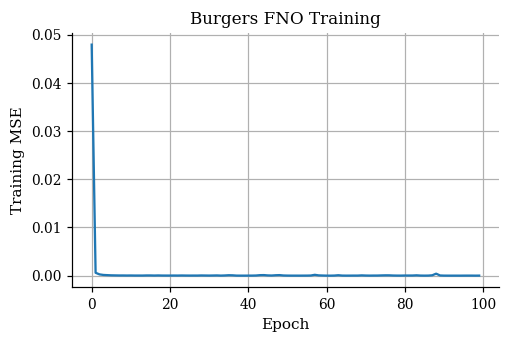

In [11]:
plt.figure(figsize=(5,3))

plt.plot(hist_b)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Burgers FNO Training")

plt.grid(True)

plt.show()

In [12]:
x_batch, y_batch = next(iter(test_loader))

print("Input :", x_batch.shape)
print("Target:", y_batch.shape)

with torch.no_grad():
    pred = burgers_fno(x_batch.to(DEVICE)).cpu()

print("Prediction:", pred.shape)
print("Hidden:", burgers_fno._hidden.shape)

Input : torch.Size([20, 256, 2])
Target: torch.Size([20, 256, 1])
Prediction: torch.Size([20, 256, 1])
Hidden: torch.Size([20, 256, 40])


# 5. Evaluation

In [20]:
burgers_fno.eval()
all_inputs=[]
all_outputs = []
all_hidden = []

with torch.no_grad():

    for x_batch, _ in test_loader:

        x_batch = x_batch.to(DEVICE)

        # Forward pass
        pred = burgers_fno(x_batch)

        all_inputs.append(x_batch.cpu())
        # Save prediction
        all_outputs.append(pred.cpu())

        # Save Fourier representation
        all_hidden.append(burgers_fno._hidden.cpu())

# Concatenate all batches
X_b = torch.cat(all_inputs).numpy()
U_b = torch.cat(all_outputs, dim=0).numpy()
H_b = torch.cat(all_hidden, dim=0).numpy()

# Save artifacts
np.save("artifacts/fno_burgers_X.npy", X_b)
np.save("artifacts/fno_burgers_U.npy", U_b)
np.save("artifacts/fno_burgers_H.npy", H_b)

print(f"Prediction shape : {U_b.shape}")
print(f"Hidden shape     : {H_b.shape}")

Prediction shape : (410, 256, 1)
Hidden shape     : (410, 256, 40)


## Figure 1 — Burgers FNO Training History

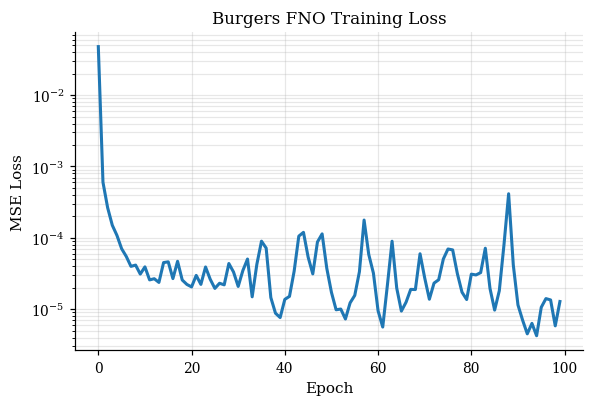

In [21]:
plt.figure(figsize=(5.5, 3.8))
plt.semilogy(hist_b, linewidth=2)

plt.title("Burgers FNO Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()

plt.savefig("figures/fig1_burgers_fno_training.png",dpi=300,bbox_inches="tight")
plt.show()

## Print final training loss

In [22]:
print("=" * 60)
print(f"{'Model':20s} {'Final MSE Loss':>18s}")
print("=" * 60)

print(f"{'Burgers FNO':20s}{hist_b[-1]:18.6e}")

Model                    Final MSE Loss
Burgers FNO               1.279272e-05


# 6. The sparse autoencoder



In [23]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=WIDTH, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H, n_epochs=SAE_EPOCHS, batch=4096, lr=1e-3, lam=LAM_L1, verbose=True):
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam*l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)


## Normalization

In [24]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu)/sd, mu, sd


H_b_flat   = H_b.reshape(-1, WIDTH)
H_b_n,   mu_b,   sd_b   = normalize(H_b_flat)

# Save normalization statistics
np.save("artifacts/fno_burgers_H_norm_mean.npy", mu_b)
np.save("artifacts/fno_burgers_H_norm_std.npy",  sd_b)

# Summary
print(f"Burgers activations: {H_b_n.shape}, mean(|h|)={np.abs(H_b_n).mean():.3f}")

Burgers activations: (104960, 40), mean(|h|)=0.747


## Train the all SAEs (~1 min each)

In [25]:
### Train all SAEs (~1 min each)

def get_sae(tag, H_norm):
    pt = f"artifacts/{tag}_sae.pt"
    if os.path.exists(pt):
        sae = SparseAutoencoder()
        sae.load_state_dict(torch.load(pt))
        hist = np.load(f"artifacts/{tag}_sae_hist.npy")
        print(f"Loaded cached SAE for {tag}.")
        return sae, hist

    print(f"Training SAE for {tag}...")
    sae, hist = train_sae(H_norm)
    torch.save(sae.state_dict(), pt)
    np.save(f"artifacts/{tag}_sae_hist.npy", hist)
    return sae, hist

# Train SAEs
sae_b,   sae_hist_b   = get_sae("burgers", H_b_n)

# Encode activations
with torch.no_grad():

    Z_b = (
        sae_b.encode(torch.from_numpy(H_b_n).float())
        .numpy()
        .reshape(H_b.shape[0], NX, DICT)
    )


# Save codes
np.save("artifacts/fno_burgers_Z.npy", Z_b)

# Summary
print(f"Burgers final L0 = {sae_hist_b[-1,3]:.1f}/{DICT}, recon = {sae_hist_b[-1,1]:.2e}")

Loaded cached SAE for burgers.
Burgers final L0 = 31.8/128, recon = 4.63e-02


In [26]:
print("H_b shape :", H_b.shape)
print("H_b_flat  :", H_b_flat.shape)
print("H_b_norm  :", H_b_n.shape)
print("Z_b       :", Z_b.shape)

H_b shape : (410, 256, 40)
H_b_flat  : (104960, 40)
H_b_norm  : (104960, 40)
Z_b       : (410, 256, 128)


# 7. Ground concepts fields

In [28]:
def concepts_fno_burgers(U, X):

    U = U.squeeze(-1)
    a = X[:, :, 0]
    xs = X[:, :, 1]
    dx = xs[0,1] - xs[0,0]
    u_x = np.gradient(U, dx, axis=1)
    u_xx = np.gradient(u_x, dx, axis=1)

    return {
        "|u|": np.abs(U),
        "u (signed)": U,
        "|u_x| (shock)": np.abs(u_x),
        "|u_xx| (curvature)": np.abs(u_xx),
        "x position": xs,
        "|a| (initial condition)": np.abs(a),
        "a (signed)": a,
    }
C_b = concepts_fno_burgers(U_b, X_b)
# Save concepts
np.savez("artifacts/fno_burgers_concepts.npz", **C_b)
# Summary
print("Burgers FNO concepts:", list(C_b.keys()))

Burgers FNO concepts: ['|u|', 'u (signed)', '|u_x| (shock)', '|u_xx| (curvature)', 'x position', '|a| (initial condition)', 'a (signed)']


# 8. Alignment

In [29]:
def alignment(Z_field, concepts):

    K = Z_field.shape[-1]
    names = list(concepts.keys())
    A = np.zeros((K, len(names)))

    for k in range(K):

        zk = Z_field[..., k].flatten()

        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)

        for j, name in enumerate(names):

            c = concepts[name].flatten()

            if c.std() < 1e-8:
                continue

            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = (zk * c).mean()

    return A, names

# sae
A_b, names_b = alignment(Z_b, C_b)
np.save("artifacts/fno_burgers_alignment.npy", A_b)


# PCA baseline
def pca_features(H_norm, n_samples):
    P = PCA(n_components=WIDTH).fit_transform(H_norm)
    return P.reshape(n_samples, NX, WIDTH)

P_b = pca_features(H_b_n, H_b.shape[0])
A_pca_b, _ = alignment(P_b, C_b)
np.save("artifacts/fno_burgers_pca_alignment.npy", A_pca_b)
np.save("artifacts/fno_burgers_alignment_names.npy",np.array(names_b, dtype=object))
print("Alignment completed.")

Alignment completed.


## Top SAE Atom vs Top PCA Component

In [30]:
def print_table(A, A_pca, names, label):

    print(f"\n{label}:")
    print(f"{'Concept':30s} | {'Top Atom':>9s} | {'SAE r':>7s} | {'Best PC':>8s} | {'PCA r':>7s}")
    print("-" * 75)

    for j, name in enumerate(names):

        k_sae = int(np.argmax(np.abs(A[:, j])))
        k_pca = int(np.argmax(np.abs(A_pca[:, j])))

        print(
            f"{name:30s} | "
            f"Atom {k_sae:3d} | "
            f"{A[k_sae, j]:+7.3f} | "
            f"PC {k_pca+1:2d} | "
            f"{A_pca[k_pca, j]:+7.3f}"
        )

print_table(A_b,A_pca_b,names_b,"Burgers FNO")


Burgers FNO:
Concept                        |  Top Atom |   SAE r |  Best PC |   PCA r
---------------------------------------------------------------------------
|u|                            | Atom  71 |  +0.550 | PC  2 |  +0.915
u (signed)                     | Atom  93 |  -0.652 | PC  1 |  -0.996
|u_x| (shock)                  | Atom 120 |  +0.858 | PC  4 |  +0.387
|u_xx| (curvature)             | Atom 120 |  +0.720 | PC  4 |  +0.445
x position                     | Atom  29 |  +0.060 | PC 40 |  -0.143
|a| (initial condition)        | Atom   2 |  +0.491 | PC  4 |  -0.683
a (signed)                     | Atom  93 |  -0.695 | PC  1 |  -0.895


In [31]:
# Mean Best Alignment
sae_best = np.max(np.abs(A_b), axis=0)
pca_best = np.max(np.abs(A_pca_b), axis=0)

print("\nMean Best Alignment")
print("-" * 35)
print(f"SAE : {sae_best.mean():.3f}")
print(f"PCA : {pca_best.mean():.3f}")


Mean Best Alignment
-----------------------------------
SAE : 0.575
PCA : 0.638


## Figure 2 — Burgers FNO Alignment Matrix (SAE vs PCA)

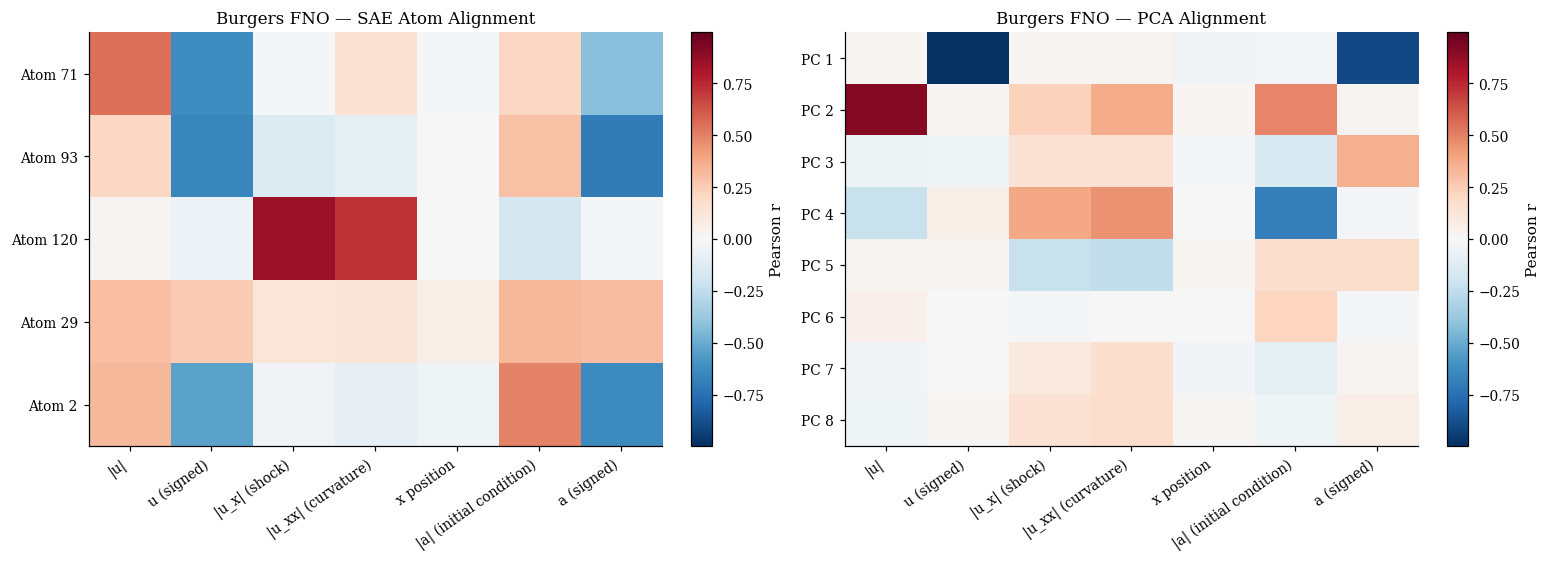

In [33]:
def fig2_fno(A, A_pca, names):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    K_pca = min(8, A_pca.shape[0])
    # SAE
    rows = [int(np.argmax(np.abs(A[:, j]))) for j in range(A.shape[1])]
    rows_unique = list(dict.fromkeys(rows))
    A_show = A[rows_unique]
    ax = axes[0]
    vmax = max(np.abs(A_show).max(),np.abs(A_pca[:K_pca]).max(),1e-3)
    im = ax.imshow(A_show,cmap="RdBu_r",vmin=-vmax,vmax=vmax,aspect="auto")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=35, ha="right")

    ax.set_yticks(range(len(rows_unique)))
    ax.set_yticklabels([f"Atom {k}" for k in rows_unique])

    ax.set_title("Burgers FNO — SAE Atom Alignment")

    plt.colorbar(im, ax=ax, fraction=0.045, label="Pearson r")

    # PCA
    ax = axes[1]
    vmax = max(np.abs(A_show).max(),np.abs(A_pca[:K_pca]).max(),1e-3)
    im = ax.imshow(A_pca[:K_pca],cmap="RdBu_r",vmin=-vmax,vmax=vmax,aspect="auto")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=35, ha="right")
    ax.set_yticks(range(K_pca))
    ax.set_yticklabels([f"PC {i+1}" for i in range(K_pca)])
    ax.set_title("Burgers FNO — PCA Alignment")
    plt.colorbar(im, ax=ax, fraction=0.045, label="Pearson r")

    plt.savefig("figures/fig2_fno_burgers_alignment.png",dpi=300,bbox_inches="tight")
    plt.show()

fig2_fno(A_b,A_pca_b,names_b)

## Figure 3 — Representative FNO Atom Activations

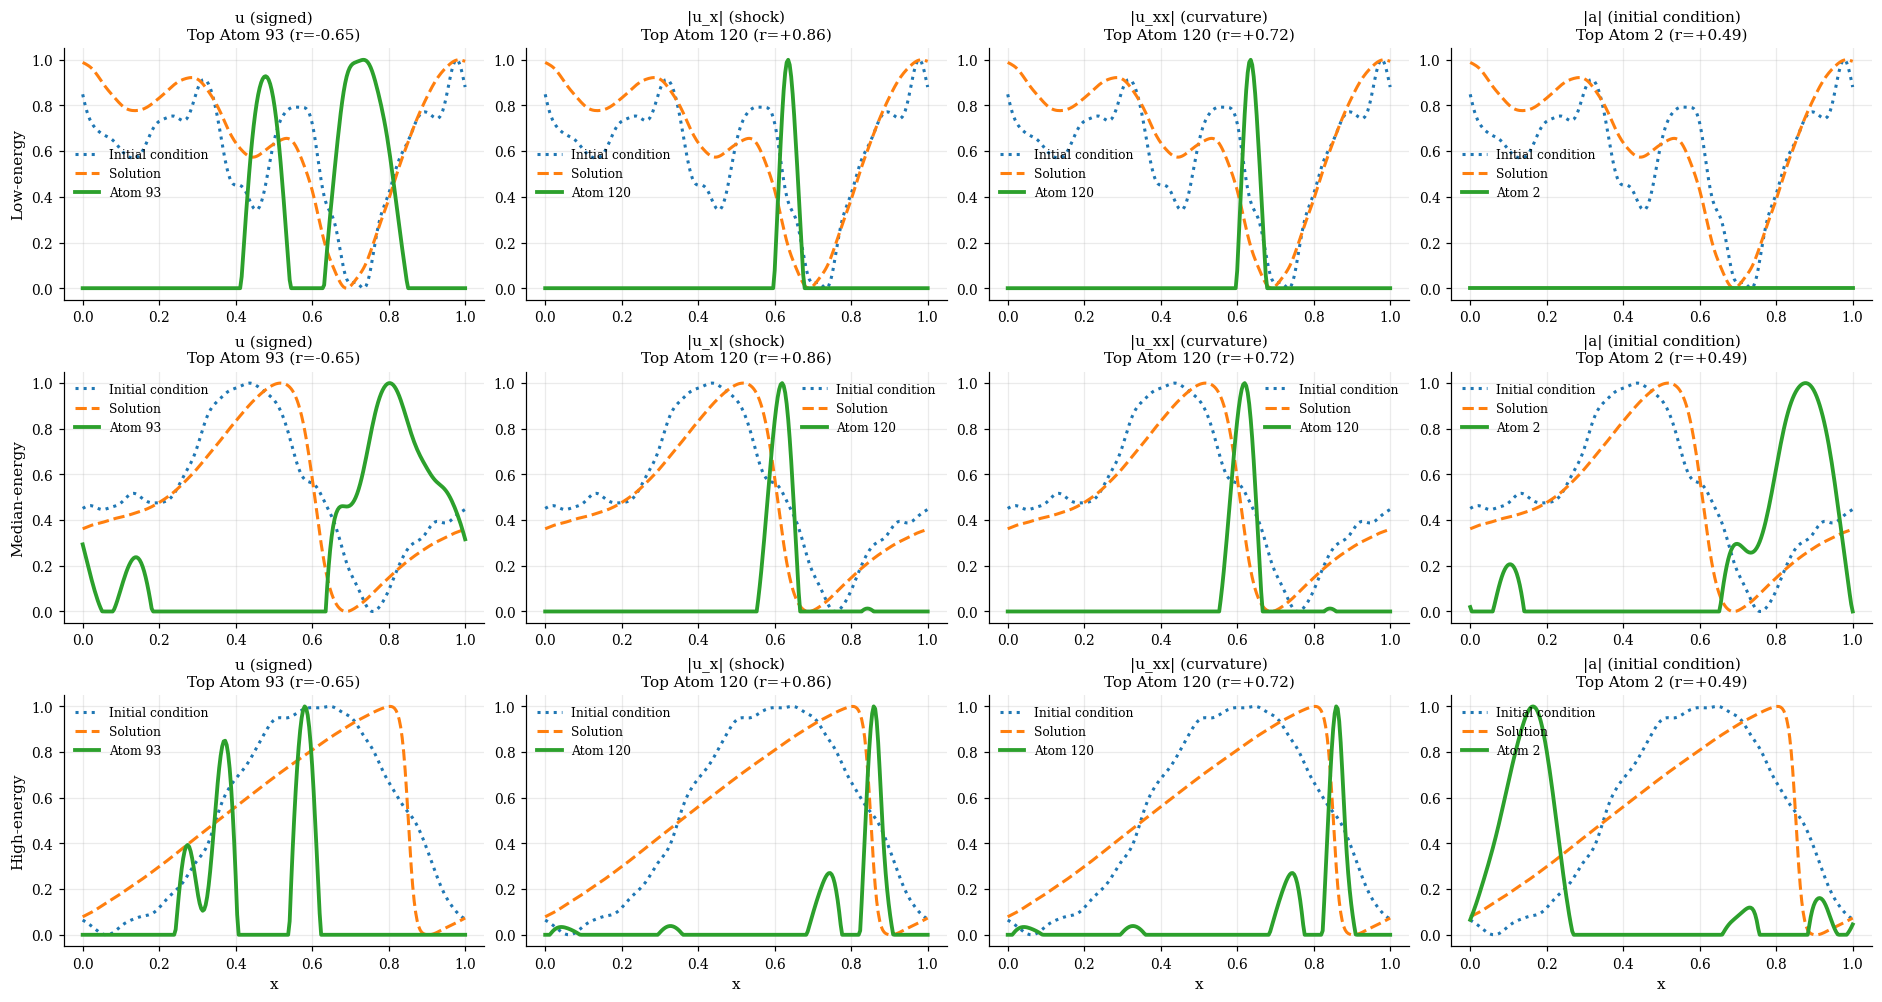

In [36]:
# Representative samples
energy = np.linalg.norm(U_b.squeeze(-1), axis=1)
sample_ids = [np.argmin(energy),np.argsort(energy)[len(energy)//2],np.argmax(energy),]
sample_labels = ["Low-energy","Median-energy","High-energy",]

# Concepts to visualize
concepts_show = ["u (signed)","|u_x| (shock)","|u_xx| (curvature)","|a| (initial condition)"]
fig, axes = plt.subplots(len(sample_ids),len(concepts_show),figsize=(17, 9),constrained_layout=True)

for row, (sample, sample_label) in enumerate(zip(sample_ids, sample_labels)):

    x = X_b[sample, :, 1]
    a = X_b[sample, :, 0]
    u = U_b[sample, :, 0]

    # Normalize for visualization
    a = (a - a.min()) / (a.max() - a.min() + 1e-8)
    u = (u - u.min()) / (u.max() - u.min() + 1e-8)

    for col, cname in enumerate(concepts_show):

        j = names_b.index(cname)
        atom = int(np.argmax(np.abs(A_b[:, j])))
        r = A_b[atom, j]

        # Normalize atom activation
        z = Z_b[sample, :, atom]
        z = (z - z.min()) / (z.max() - z.min() + 1e-8)

        ax = axes[row, col]

        ax.plot(x,a,":",lw=2,label="Initial condition")
        ax.plot(x,u,"--",lw=2,label="Solution")

        ax.plot(x,z,lw=2.5,label=f"Atom {atom}")
        ax.set_ylim(-0.05, 1.05)

        ax.set_title(f"{cname}\nTop Atom {atom} (r={r:+.2f})",fontsize=10)

        if row == len(sample_ids) - 1:
            ax.set_xlabel("x")

        if col == 0:
            ax.set_ylabel(sample_label)

        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)

plt.savefig("figures/fig3_fno_top_atoms.png",dpi=300,bbox_inches="tight")
plt.show()

# Ablation

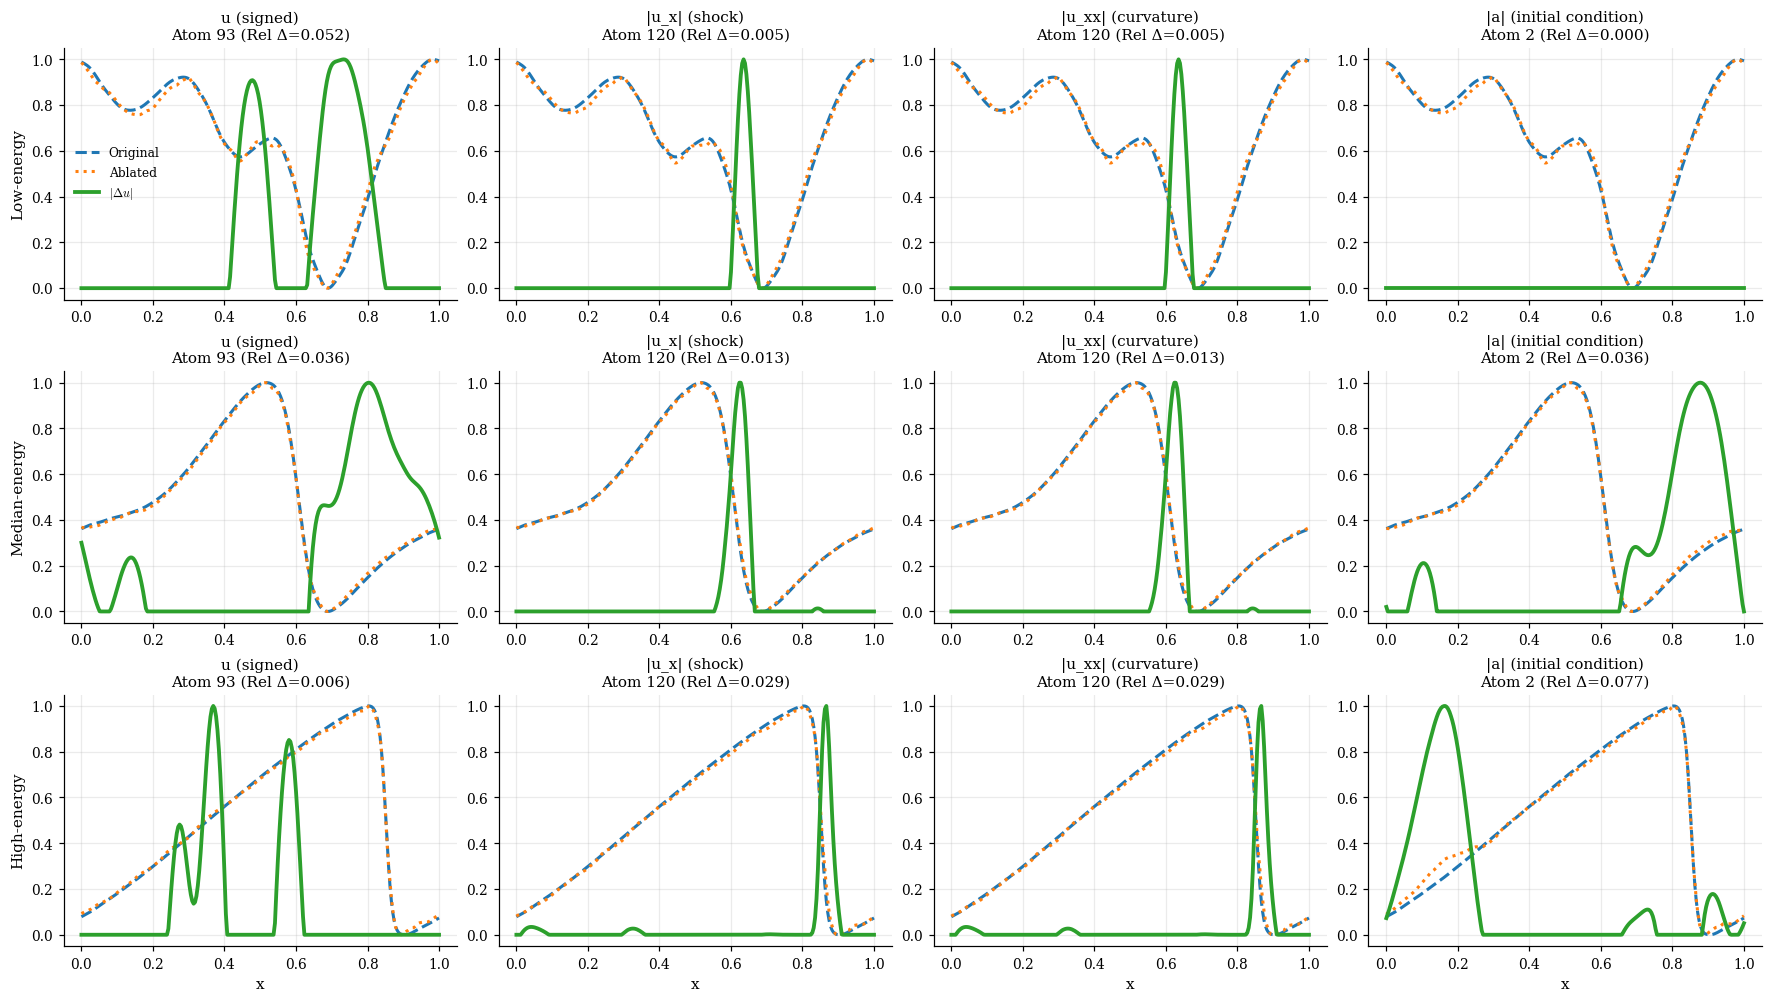

In [41]:
def intervene_ablate_fno(model, sae, H, mu, sd, atom_idx):

    # Flatten hidden features
    H_flat = H.reshape(-1, WIDTH)
    H_norm = (H_flat - mu) / sd
    Ht = torch.from_numpy(H_norm).float()

    with torch.no_grad():

        # Encode
        z = sae.encode(Ht)
        # Normal reconstruction
        h_rec_norm = sae.decode(z)
        # Ablate one atom
        z_mod = z.clone()
        z_mod[:, atom_idx] = 0.0

        h_mod_norm = sae.decode(z_mod)

    # Undo normalization
    h_rec = h_rec_norm.numpy() * sd + mu
    h_mod = h_mod_norm.numpy() * sd + mu

    # Convert back to tensors
    h_rec = torch.from_numpy(h_rec).float()
    h_mod = torch.from_numpy(h_mod).float()

    with torch.no_grad():

        # Replay final FNO head
        u_rec = model.fc2(
            F.gelu(
                model.fc1(h_rec)
            )
        )

        u_mod = model.fc2(
            F.gelu(
                model.fc1(h_mod)
            )
        )

    u_rec = u_rec.numpy().reshape(H.shape[0], NX)
    u_mod = u_mod.numpy().reshape(H.shape[0], NX)

    delta = u_rec - u_mod

    return u_rec, u_mod, delta

concepts_show = ["u (signed)","|u_x| (shock)","|u_xx| (curvature)","|a| (initial condition)"]

# Same representative samples as Figure 3
energy = np.linalg.norm(U_b.squeeze(-1), axis=1)
sample_ids = [np.argmin(energy),np.argsort(energy)[len(energy)//2],np.argmax(energy),]
sample_labels = ["Low-energy","Median-energy","High-energy",]
fig, axes = plt.subplots(len(sample_ids),len(concepts_show),figsize=(16,9),constrained_layout=True)

for row, (sample, sample_label) in enumerate(zip(sample_ids, sample_labels)):

    x = X_b[sample,:,1]

    for col, cname in enumerate(concepts_show):

        idx = names_b.index(cname)
        atom = int(np.argmax(np.abs(A_b[:,idx])))

        u_rec, u_mod, delta = intervene_ablate_fno(burgers_fno,sae_b,H_b,mu_b,sd_b,atom)

        ax = axes[row,col]

        # Original solution
        u = U_b[sample,:,0]
        u = (u-u.min())/(u.max()-u.min()+1e-8)

        # Ablated solution
        ua = u_mod[sample]
        ua = (ua-ua.min())/(ua.max()-ua.min()+1e-8)

        # Absolute intervention effect
        d = np.abs(delta[sample])
        d = d/(d.max()+1e-8)

        ax.plot(x, u, "--", lw=2, label="Original")
        ax.plot(x, ua, ":", lw=2, label="Ablated")
        ax.plot(x, d, lw=2.5, label=r"$|\Delta u|$")

        rel = np.linalg.norm(delta[sample]) / (
            np.linalg.norm(u_rec[sample]) + 1e-12
        )

        ax.set_ylim(-0.05,1.05)

        ax.set_title(
            f"{cname}\nAtom {atom} (Rel Δ={rel:.3f})",
            fontsize=10
        )

        if row == len(sample_ids)-1:
            ax.set_xlabel("x")

        if col == 0:
            ax.set_ylabel(sample_label)

        ax.grid(alpha=0.25)

        if row == 0 and col == 0:
            ax.legend(frameon=False, fontsize=8)

plt.savefig(
    "figures/fig4_fno_intervention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Training dynamics - sae v/s pca

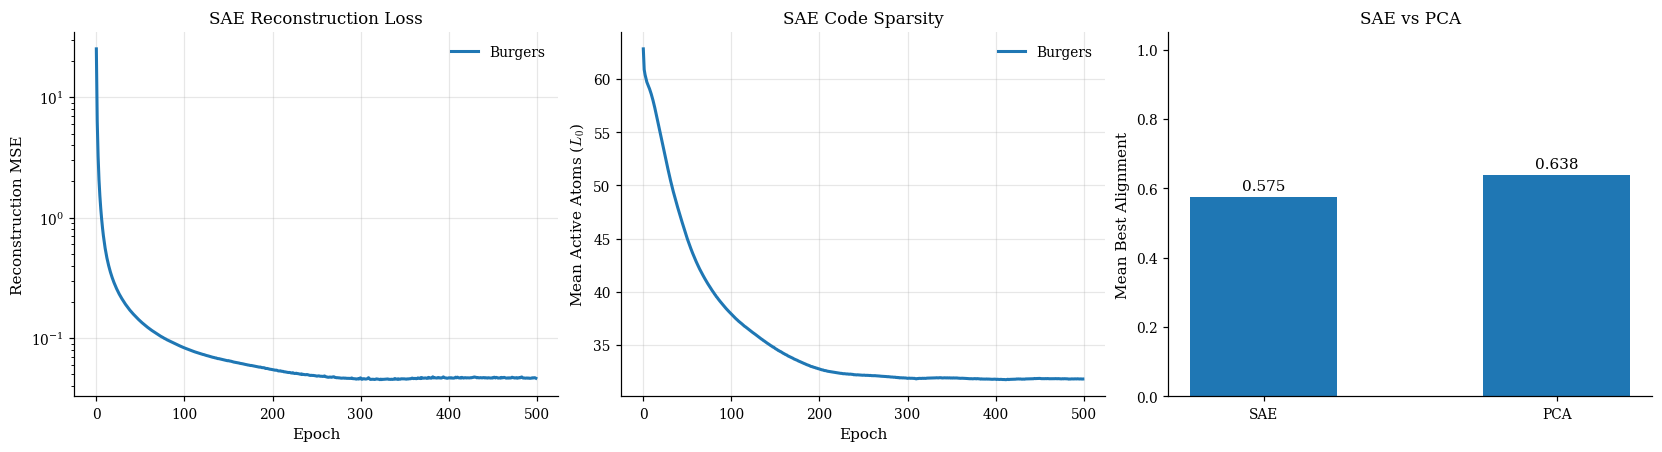

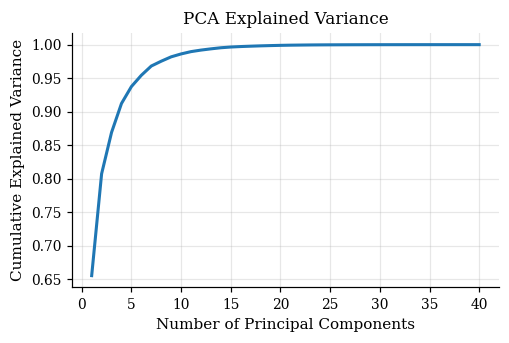

Final SAE Statistics
Final Reconstruction Loss : 4.631234e-02
Final Mean L0            : 31.80
Mean SAE Alignment       : 0.575
Mean PCA Alignment       : 0.638

Cumulative Explained Variance
[0.65546864 0.80742645 0.8691245  0.91224945 0.937487   0.9543256
 0.96811116 0.9753084  0.9818187  0.9861473  0.9896001  0.9918793
 0.9937258  0.9953695  0.9964619  0.9971585  0.9977051  0.99819726
 0.99859667 0.9989435  0.9992102  0.9993875  0.9995434  0.99965847
 0.9997321  0.99978995 0.999836   0.99987006 0.9999002  0.99992514
 0.999943   0.99995625 0.9999677  0.9999771  0.9999845  0.9999907
 0.9999943  0.9999967  0.99999857 1.0000001 ]


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), constrained_layout=True)


# SAE Reconstruction Loss
ax = axes[0]
ax.plot(sae_hist_b[:,1], lw=2, label="Burgers")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("SAE Reconstruction Loss")
ax.grid(alpha=0.3)
ax.legend(frameon=False)


# Code Sparsity
ax = axes[1]
ax.plot(sae_hist_b[:,3], lw=2, label="Burgers")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"Mean Active Atoms ($L_0$)")
ax.set_title("SAE Code Sparsity")
ax.grid(alpha=0.3)
ax.legend(frameon=False)



# SAE vs PCA Alignment
ax = axes[2]
sae_score = np.max(np.abs(A_b), axis=0).mean()
pca_score = np.max(np.abs(A_pca_b), axis=0).mean()
ax.bar(["SAE", "PCA"],[sae_score, pca_score],width=0.5)
ax.set_ylim(0,1.05)
ax.set_ylabel("Mean Best Alignment")
ax.set_title("SAE vs PCA")

for i, v in enumerate([sae_score, pca_score]):
    ax.text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.savefig("figures/fig5_fno_training_summary.png",dpi=300,bbox_inches="tight")
plt.show()


# PCA Explained Variance
pca = PCA(n_components=WIDTH)
pca.fit(H_b_n)

plt.figure(figsize=(5,3))
plt.plot(np.arange(1, WIDTH+1),np.cumsum(pca.explained_variance_ratio_),lw=2)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(alpha=0.3)

plt.savefig("figures/fig5_pca_variance.png",dpi=300,bbox_inches="tight")
plt.show()


print("="*60)
print("Final SAE Statistics")
print("="*60)

print(f"Final Reconstruction Loss : {sae_hist_b[-1,1]:.6e}")
print(f"Final Mean L0            : {sae_hist_b[-1,3]:.2f}")
print(f"Mean SAE Alignment       : {sae_score:.3f}")
print(f"Mean PCA Alignment       : {pca_score:.3f}")

print("\nCumulative Explained Variance")
print(np.cumsum(pca.explained_variance_ratio_))

# Monosemanticity Metrics

## Main code

In [43]:
def monosemanticity_scores(A):
    """
    Monosemanticity score of each atom/component.

    m_k = max_j |A[k,j]|
    """
    return np.max(np.abs(A), axis=1)


# ---------- SAE ----------
mk_b = monosemanticity_scores(A_b)

# ---------- PCA ----------
mk_pca_b = monosemanticity_scores(A_pca_b)

print("Monosemanticity scores computed.")
print(f"SAE atoms : {mk_b.shape}")
print(f"PCA comps : {mk_pca_b.shape}")

Monosemanticity scores computed.
SAE atoms : (128,)
PCA comps : (40,)


## Monosemantic Atom Fraction

In [44]:
THRESHOLD = 0.6

def monosemantic_fraction(mk, threshold=THRESHOLD):
    """
    Fraction of atoms/components whose
    monosemanticity exceeds the threshold.
    """
    return np.mean(mk > threshold)


# ---------- SAE ----------
frac_b = monosemantic_fraction(mk_b)

# ---------- PCA ----------
frac_pca_b = monosemantic_fraction(mk_pca_b)


print("="*45)
print("Monosemantic Atom Fraction")
print("="*45)

print(f"Threshold : {THRESHOLD:.2f}\n")
print(f"SAE : {frac_b:.3f}")
print(f"PCA : {frac_pca_b:.3f}")

Monosemantic Atom Fraction
Threshold : 0.60

SAE : 0.094
PCA : 0.075


## Feature Density

In [45]:
EPSILON = 1e-6

def feature_density(Z, eps=EPSILON):
    """
    Feature density of each latent feature.

    density_k =
        fraction of spatial locations where
        |feature activation| > eps

    Parameters
    ----------
    Z : ndarray (..., K)

    Returns
    -------
    density : ndarray (K,)
    """

    Z_flat = Z.reshape(-1, Z.shape[-1])

    return np.mean(np.abs(Z_flat) > eps, axis=0)

# SAE
density_b = feature_density(Z_b)

# PCA
density_pca_b = feature_density(P_b)

print("="*60)
print("Feature Density")
print("="*60)

print(f"SAE atoms : {density_b.shape}")
print(f"PCA comps : {density_pca_b.shape}")

print()

print(f"Mean SAE density : {density_b.mean():.3f}")
print(f"Mean PCA density : {density_pca_b.mean():.3f}")

Feature Density
SAE atoms : (128,)
PCA comps : (40,)

Mean SAE density : 0.248
Mean PCA density : 1.000


## summary stats

In [46]:
def summary_statistics(mk, density, fraction):
    """
    Compute summary statistics for one dataset.
    """
    return {
        "mean_mk": np.mean(mk),
        "median_mk": np.median(mk),
        "std_mk": np.std(mk),

        "fraction_gt_0.6": fraction,

        "mean_density": np.mean(density),
        "median_density": np.median(density),
        "std_density": np.std(density),
    }

# SAE
summary_sae = {"Burgers FNO": summary_statistics(mk_b,density_b,frac_b)}
# PCA
summary_pca = {"Burgers FNO": summary_statistics(mk_pca_b,density_pca_b,frac_pca_b)}

# Print Summary
for dataset in summary_sae:

    print("\n" + "="*60)
    print(dataset)
    print("="*60)

    print("\nSAE")
    for k, v in summary_sae[dataset].items():
        print(f"{k:20s}: {v:.4f}")

    print("\nPCA")
    for k, v in summary_pca[dataset].items():
        print(f"{k:20s}: {v:.4f}")


Burgers FNO

SAE
mean_mk             : 0.4122
median_mk           : 0.4141
std_mk              : 0.1452
fraction_gt_0.6     : 0.0938
mean_density        : 0.2483
median_density      : 0.2555
std_density         : 0.1047

PCA
mean_mk             : 0.1987
median_mk           : 0.1328
std_mk              : 0.2082
fraction_gt_0.6     : 0.0750
mean_density        : 1.0000
median_density      : 1.0000
std_density         : 0.0000


## Plots - Monosemtanticity

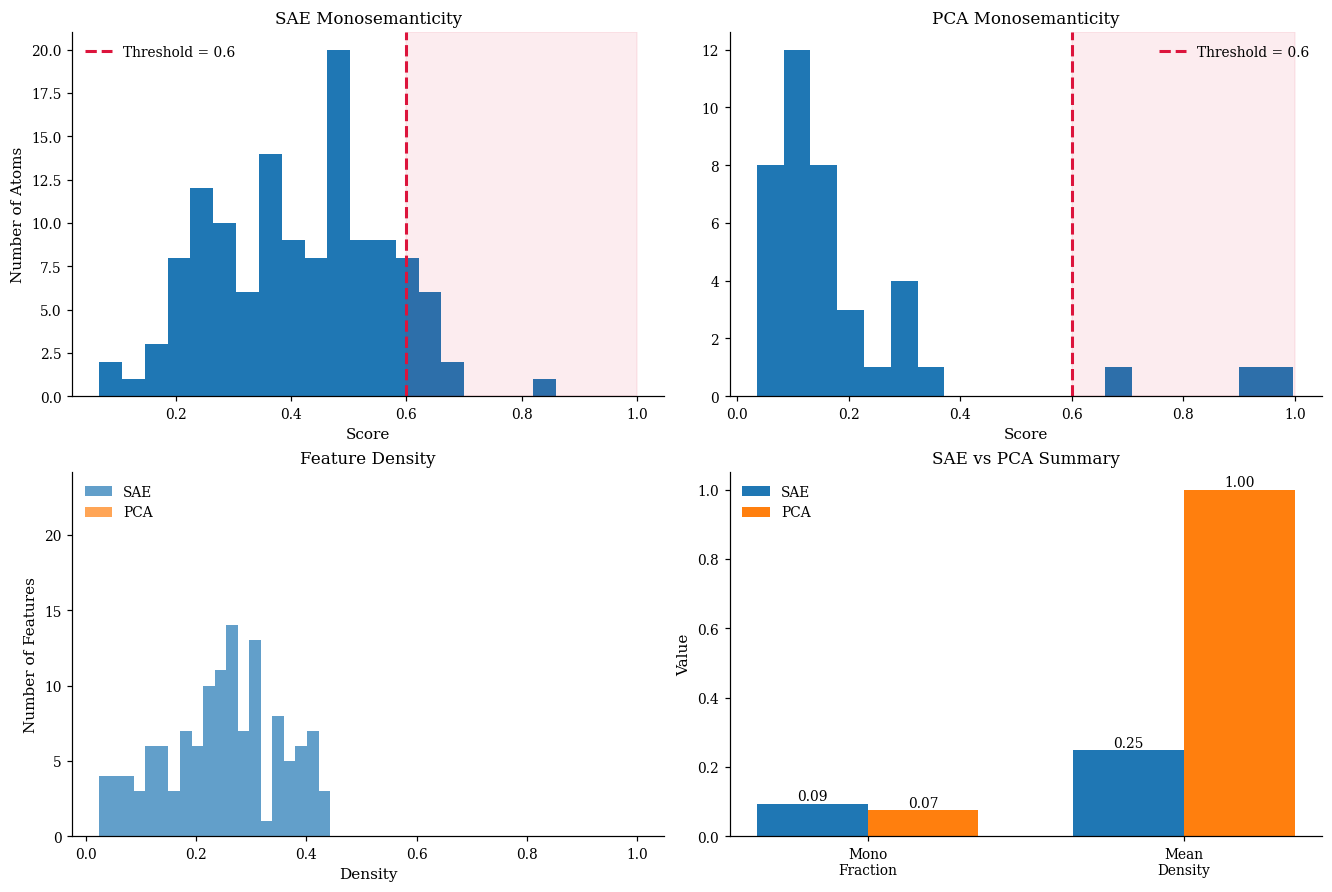

In [47]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# (a) Monosemanticity Histogram - SAE
axes[0,0].hist(mk_b, bins=20)
axes[0,0].axvline(THRESHOLD,color="crimson",linestyle="--",linewidth=2,label=f"Threshold = {THRESHOLD}")
axes[0,0].axvspan(THRESHOLD,1.0,color="crimson",alpha=0.08)
axes[0,0].set_title("SAE Monosemanticity")
axes[0,0].set_xlabel("Score")
axes[0,0].set_ylabel("Number of Atoms")
axes[0,0].legend(frameon=False)


# (b) Monosemanticity Histogram - PCA
axes[0,1].hist(mk_pca_b, bins=20)
axes[0,1].axvline(THRESHOLD,color="crimson",linestyle="--",linewidth=2,label=f"Threshold = {THRESHOLD}")
axes[0,1].axvspan(THRESHOLD,1.0,color="crimson",alpha=0.08)
axes[0,1].set_title("PCA Monosemanticity")
axes[0,1].set_xlabel("Score")
axes[0,1].legend(frameon=False)

# (c) Feature Density
axes[1,0].hist(density_b,bins=20,alpha=0.7,label="SAE")
axes[1,0].hist(density_pca_b,bins=20,alpha=0.7,label="PCA")
axes[1,0].set_title("Feature Density")
axes[1,0].set_xlabel("Density")
axes[1,0].set_ylabel("Number of Features")
axes[1,0].legend(frameon=False)


# (d) Summary Comparison
labels = ["Mono\nFraction","Mean\nDensity"]
sae_vals = [frac_b,density_b.mean()]
pca_vals = [frac_pca_b,density_pca_b.mean()]
x = np.arange(len(labels))
w = 0.35

axes[1,1].bar(x-w/2,sae_vals,width=w,label="SAE")
axes[1,1].bar(x+w/2,pca_vals,width=w,label="PCA")

axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(labels)

axes[1,1].set_ylabel("Value")
axes[1,1].set_title("SAE vs PCA Summary")
axes[1,1].legend(frameon=False)

for i, v in enumerate(sae_vals):
    axes[1,1].text(i-w/2,v+0.01,f"{v:.2f}",ha="center",fontsize=9)

for i, v in enumerate(pca_vals):
    axes[1,1].text(i+w/2,v+0.01,f"{v:.2f}",ha="center",fontsize=9)

plt.savefig("figures/fig8_fno_monosemanticity_density.png",dpi=300,bbox_inches="tight")
plt.show()

# Two-sided alignment

## Find positive and negative atoms

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def find_two_sided_atoms(A, names):
    """
    For each concept:
      - atom with maximum positive correlation
      - atom with maximum negative correlation
    """

    results = {}

    for j, concept in enumerate(names):

        k_pos = int(np.argmax(A[:, j]))
        k_neg = int(np.argmin(A[:, j]))

        results[concept] = {
            "k_pos": k_pos,
            "r_pos": A[k_pos, j],
            "k_neg": k_neg,
            "r_neg": A[k_neg, j],
        }

    return results


# ------------------------------------------------------------
# Burgers FNO
# ------------------------------------------------------------

two_b = find_two_sided_atoms(A_b, names_b)

print("Two-sided atom search completed.")

Two-sided atom search completed.


## Print Two-Sided Atom Table

In [49]:
def print_two_sided(results, label):

    print("\n" + "="*80)
    print(label)
    print("="*80)

    print(
        f"{'Concept':30s}"
        f"{'Pos Atom':>12s}"
        f"{'r+':>10s}"
        f"{'Neg Atom':>12s}"
        f"{'r-':>10s}"
    )

    print("-"*80)

    for concept, info in results.items():

        print(
            f"{concept:30s}"
            f"{info['k_pos']:12d}"
            f"{info['r_pos']:10.3f}"
            f"{info['k_neg']:12d}"
            f"{info['r_neg']:10.3f}"
        )


# ------------------------------------------------------------
# Burgers FNO
# ------------------------------------------------------------

print_two_sided(two_b, "Burgers FNO")


Burgers FNO
Concept                           Pos Atom        r+    Neg Atom        r-
--------------------------------------------------------------------------------
|u|                                     71     0.550          65    -0.439
u (signed)                              46     0.636          93    -0.652
|u_x| (shock)                          120     0.858         124    -0.167
|u_xx| (curvature)                     120     0.720          41    -0.142
x position                              29     0.060          66    -0.044
|a| (initial condition)                  2     0.491          65    -0.394
a (signed)                              73     0.654          93    -0.695


## Joint Regression (Positive + Negative Atom)

In [50]:
def two_sided_regression(Z, concepts, names, results):
    """
    Fit a linear model using the best positive and
    best negative atom for each concept.
    """

    scores = {}

    for concept in names:

        info = results[concept]

        k_pos = info["k_pos"]
        k_neg = info["k_neg"]

        X = np.column_stack([
            Z[..., k_pos].flatten(),
            Z[..., k_neg].flatten()
        ])

        y = concepts[concept].flatten()

        model = LinearRegression()
        model.fit(X, y)

        y_pred = model.predict(X)

        scores[concept] = {
            "R2": r2_score(y, y_pred),
            "k_pos": k_pos,
            "k_neg": k_neg,
        }

    return scores


# ------------------------------------------------------------
# Burgers FNO
# ------------------------------------------------------------

R2_b = two_sided_regression(
    Z_b,
    C_b,
    names_b,
    two_b
)

print("Two-sided regression completed.")

Two-sided regression completed.


## Print Joint Regression R²

In [51]:
def print_r2(scores, label):

    print("\n" + "="*60)
    print(label)
    print("="*60)

    print(f"{'Concept':30s}{'Joint R²':>15s}")
    print("-"*60)

    for concept, info in scores.items():

        print(
            f"{concept:30s}"
            f"{info['R2']:15.3f}"
        )


# ------------------------------------------------------------
# Burgers FNO
# ------------------------------------------------------------

print_r2(R2_b, "Burgers FNO")


Burgers FNO
Concept                              Joint R²
------------------------------------------------------------
|u|                                     0.429
u (signed)                              0.612
|u_x| (shock)                           0.742
|u_xx| (curvature)                      0.522
x position                              0.005
|a| (initial condition)                 0.344
a (signed)                              0.661


## Single vs Two-Atom Regression Comparison

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def compare_single_vs_pair(Z, concepts, names, A, two_results):
    """
    Compare the original single-atom regression against the
    proposed positive+negative atom regression.
    """

    comparison = {}

    for j, concept in enumerate(names):

        y = concepts[concept].flatten()

        # ----------------------------------------------------
        # Best single atom
        # ----------------------------------------------------

        k_single = int(np.argmax(np.abs(A[:, j])))

        X_single = Z[..., k_single].reshape(-1, 1)

        model_single = LinearRegression()
        model_single.fit(X_single, y)

        pred_single = model_single.predict(X_single)

        R2_single = r2_score(y, pred_single)

        # ----------------------------------------------------
        # Positive + Negative atoms
        # ----------------------------------------------------

        k_pos = two_results[concept]["k_pos"]
        k_neg = two_results[concept]["k_neg"]

        X_pair = np.column_stack([
            Z[..., k_pos].flatten(),
            Z[..., k_neg].flatten()
        ])

        model_pair = LinearRegression()
        model_pair.fit(X_pair, y)

        pred_pair = model_pair.predict(X_pair)

        R2_pair = r2_score(y, pred_pair)

        comparison[concept] = {
            "single_atom": k_single,
            "positive_atom": k_pos,
            "negative_atom": k_neg,
            "same_atom": (k_single == k_pos) or (k_single == k_neg),
            "pair_split": (k_pos != k_neg),
            "R2_single": R2_single,
            "R2_pair": R2_pair,
            "delta_R2": R2_pair - R2_single,
        }

    return comparison


# ------------------------------------------------------------
# Pretty printer
# ------------------------------------------------------------

def print_comparison(comparison, title):

    print("\n" + "="*105)
    print(title)
    print("="*105)

    print(
        f"{'Concept':30s}"
        f"{'Single':>8s}"
        f"{'Pos':>8s}"
        f"{'Neg':>8s}"
        f"{'Single R²':>12s}"
        f"{'Pair R²':>12s}"
        f"{'ΔR²':>10s}"
        f"{'Improvement %':>17s}"
    )

    print("-"*105)

    for concept, info in comparison.items():

        r2_single = info["R2_single"]
        r2_pair = info["R2_pair"]

        delta = info["delta_R2"]

        if abs(r2_single) > 1e-12:
            improvement = 100 * delta / abs(r2_single)
            improvement_str = f"{improvement:.1f}%"
        else:
            improvement_str = "N/A"

        print(
            f"{concept:30s}"
            f"{info['single_atom']:8d}"
            f"{info['positive_atom']:8d}"
            f"{info['negative_atom']:8d}"
            f"{r2_single:12.3f}"
            f"{r2_pair:12.3f}"
            f"{delta:10.3f}"
            f"{improvement_str:>17s}"
        )


# ------------------------------------------------------------
# Burgers FNO
# ------------------------------------------------------------

cmp_b = compare_single_vs_pair(
    Z_b,
    C_b,
    names_b,
    A_b,
    two_b,
)

print_comparison(cmp_b, "Burgers FNO")


Burgers FNO
Concept                         Single     Pos     Neg   Single R²     Pair R²       ΔR²    Improvement %
---------------------------------------------------------------------------------------------------------
|u|                                 71      71      65       0.302       0.429     0.126            41.9%
u (signed)                          93      46      93       0.425       0.612     0.186            43.9%
|u_x| (shock)                      120     120     124       0.737       0.742     0.006             0.8%
|u_xx| (curvature)                 120     120      41       0.518       0.522     0.004             0.7%
x position                          29      29      66       0.004       0.005     0.002            46.0%
|a| (initial condition)              2       2      65       0.241       0.344     0.103            42.8%
a (signed)                          93      73      93       0.483       0.661     0.178            36.8%


## Figure — Two-Sided Alignment (FNO)

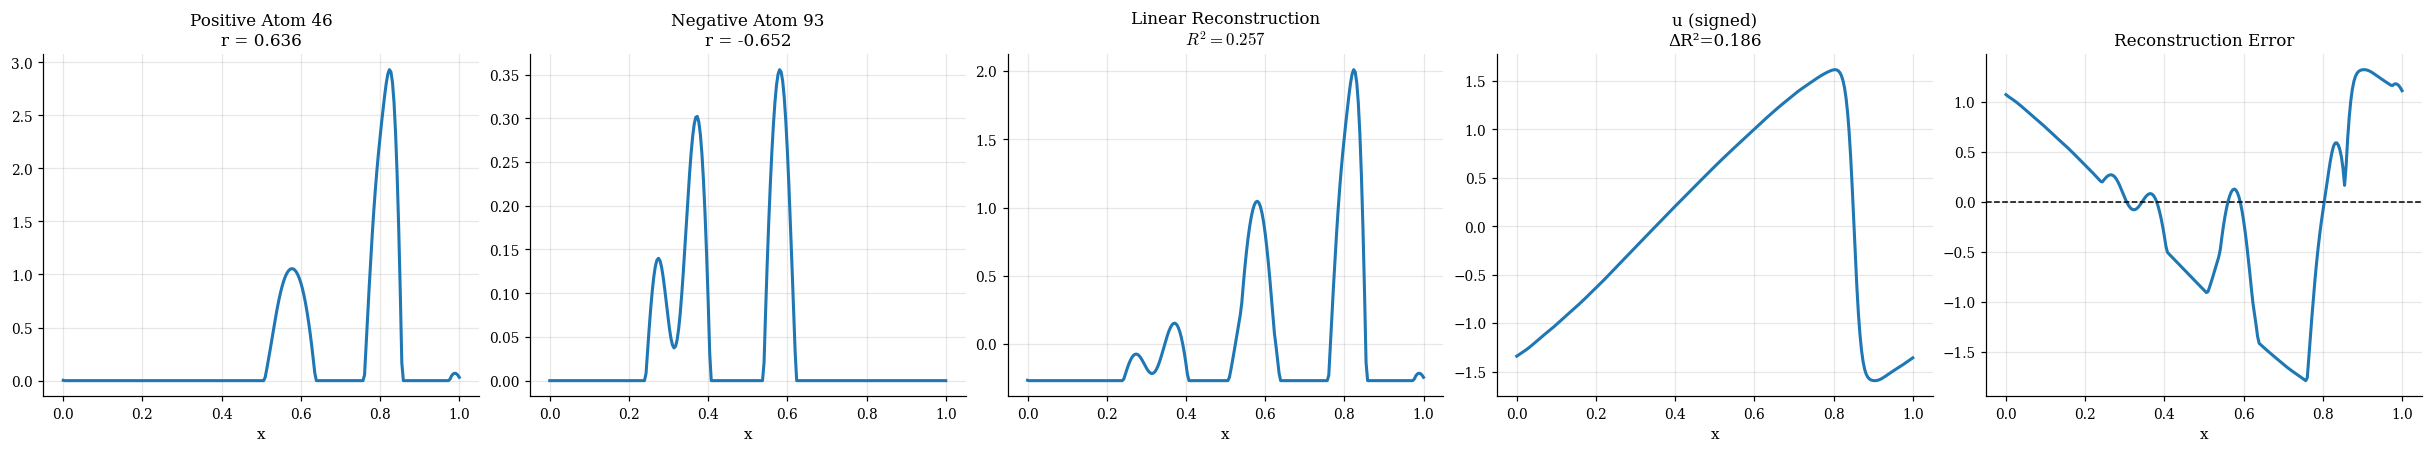

In [53]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np


def best_improvement(comparison):
    return max(
        comparison.keys(),
        key=lambda c: comparison[c]["delta_R2"]
    )


# ------------------------------------------------------------
# Choose concept with largest improvement
# ------------------------------------------------------------

concept_name = best_improvement(cmp_b)

info = two_b[concept_name]

k_pos = info["k_pos"]
k_neg = info["k_neg"]

# Representative sample (largest solution energy)
sample = np.argmax(np.linalg.norm(U_b.squeeze(-1), axis=1))

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

pos = Z_b[sample, :, k_pos]
neg = Z_b[sample, :, k_neg]

concept = C_b[concept_name][sample]

X = np.column_stack([pos, neg])

model = LinearRegression()
model.fit(X, concept)

pred = model.predict(X)

error = pred - concept

R2 = r2_score(concept, pred)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22,4),
    constrained_layout=True
)

# Positive atom
axes[0].plot(X_b[sample,:,1], pos, lw=2)
axes[0].set_title(
    f"Positive Atom {k_pos}\n"
    f"r = {info['r_pos']:.3f}"
)
axes[0].set_xlabel("x")
axes[0].grid(alpha=0.3)

# Negative atom
axes[1].plot(X_b[sample,:,1], neg, lw=2)
axes[1].set_title(
    f"Negative Atom {k_neg}\n"
    f"r = {info['r_neg']:.3f}"
)
axes[1].set_xlabel("x")
axes[1].grid(alpha=0.3)

# Reconstruction
axes[2].plot(
    X_b[sample,:,1],
    pred,
    lw=2
)
axes[2].set_title(f"Linear Reconstruction\n$R^2={R2:.3f}$")
axes[2].set_xlabel("x")
axes[2].grid(alpha=0.3)

# Ground truth
axes[3].plot(
    X_b[sample,:,1],
    concept,
    lw=2
)
axes[3].set_title(
    concept_name +
    f"\nΔR²={cmp_b[concept_name]['delta_R2']:.3f}"
)
axes[3].set_xlabel("x")
axes[3].grid(alpha=0.3)

# Error
axes[4].plot(
    X_b[sample,:,1],
    error,
    lw=2
)
axes[4].axhline(
    0,
    color="black",
    ls="--",
    lw=1
)

axes[4].set_title("Reconstruction Error")
axes[4].set_xlabel("x")
axes[4].grid(alpha=0.3)

plt.savefig(
    "figures/fig_two_sided_alignment_fno.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()